# IMPORTING LIBRARIES

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import wget
import shutil
import os
import librosa

# Machine learning and PyTorch
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torch.hub import load_state_dict_from_url


# Importar project modules
from traintest_without_GRL import train_without_GRL, validate_without_GRL, cross_validate_and_save
import models
from models import *
from utilities import *
import dataloader
from data import humv_loader

import warnings
warnings.filterwarnings("ignore")




# checking librosa version
print("librosa version:", librosa.__version__)

# changing the current working directory to the src folder
os.chdir("/home/marcos/Documentos/GitHub/TFM_code/src")
print("Current working directory:", os.getcwd())  # Print the current working directory to confirm

# Specify a directory that is writable
os.environ['TORCH_HOME'] = "/home/marcos/Documentos/GitHub/TFM_code/pretrained_models"
print("TORCH_HOME set to:", os.environ['TORCH_HOME'])  # Print the TORCH_HOME environment variable to confirm

librosa version: 0.11.0
Current working directory: /home/marcos/Documentos/GitHub/TFM_code/src
TORCH_HOME set to: /home/marcos/Documentos/GitHub/TFM_code/pretrained_models


# LOADING HC VS PD DATA

In [2]:
from data.load_preprocessed_data import load_preprocessed_data, combine_preprocessed_data

# processed_folder = '/home/marcos/Documentos/GitHub/TFM_code/data/processed/5s_with_1s_overlap'
processed_folder = '/home/marcos/Documentos/GitHub/TFM_code/data/processed/5s_with_1s_overlap_16kHz_top_db_20'

# Load all pre-processed data
data = load_preprocessed_data(processed_folder, pattern_type='audio_segments_5s_with_1s_overlap_*.npy', exercise_names=None)

# Combine into single dataset for your study
combined = combine_preprocessed_data(data)

# Access the data
audio_segments = combined['audio_segments']      # Shape: (n_samples, n_timepoints)
labels = combined['labels']                      # Shape: (n_samples,)
patient_ids = combined['patient_ids']            # Patient identifiers
exercises = combined['exercises']                # Exercise names

# Separate data into two groups
# Group 1: Labels 0 and 2 (e.g., HC and PD)
mask_HC_PD = np.isin(labels, [0, 2])
audio_segments_HC_PD = audio_segments[mask_HC_PD]
labels_HC_PD = labels[mask_HC_PD].copy()
patient_ids_HC_PD = patient_ids[mask_HC_PD]
exercises_HC_PD = exercises[mask_HC_PD]

# Replace label 2 with 1 in group1
labels_HC_PD = np.where(labels_HC_PD == 2, 1, labels_HC_PD)

# Group 2: Label 1 (e.g., AC)
mask_AC = labels == 1
audio_segments_AC = audio_segments[mask_AC]
labels_AC = labels[mask_AC].copy()
patient_ids_AC = patient_ids[mask_AC]
exercises_AC = exercises[mask_AC]

# Define normal DaTSCAN patients - for group2
normal_DaTSCAN_patient_ids = ['HUMV_AC_25', 'HUMV_AC_1', 'HUMV_AC_33', 'HUMV_AC_3']

# Change label from 1 to 0 for normal DaTSCAN patients in group2
for i, patient_id in enumerate(patient_ids_AC):
    if patient_id in normal_DaTSCAN_patient_ids:
        labels_AC[i] = 0

# Print summary
print(f"Group 1 (Labels 0 & 2 → remapped to 0 & 1): {audio_segments_HC_PD.shape[0]} samples")
print(f"  - Label 0: {sum(labels_HC_PD == 0)} samples")
print(f"  - Label 1: {sum(labels_HC_PD == 1)} samples")
print(f"\nGroup 2 (Label 1 → remapped): {audio_segments_AC.shape[0]} samples")
print(f"  - Label 0 (normal DaTSCAN): {sum(labels_AC == 0)} samples")
print(f"  - Label 1 (abnormal DaTSCAN): {sum(labels_AC == 1)} samples")

✓ Loaded 'aueoi': 179 samples, shape (179, 80000)
✓ Loaded 'fluencia categorial': 834 samples, shape (834, 80000)
✓ Loaded 'habla libre': 580 samples, shape (580, 80000)
✓ Loaded 'ka': 189 samples, shape (189, 80000)
✓ Loaded 'lectura texto': 3285 samples, shape (3285, 80000)
✓ Loaded 'pa': 183 samples, shape (183, 80000)
✓ Loaded 'patachaka': 146 samples, shape (146, 80000)
✓ Loaded 'pataka': 121 samples, shape (121, 80000)
✓ Loaded 'robo galletas': 520 samples, shape (520, 80000)
✓ Loaded 'ta': 186 samples, shape (186, 80000)
✓ Loaded 'uy': 123 samples, shape (123, 80000)
✓ Loaded 'vocal': 20 samples, shape (20, 80000)

✓ Combined all exercises: 6366 total samples
  Shape: (6366, 80000)
  Label distribution: [2527 1952 1887]
Group 1 (Labels 0 & 2 → remapped to 0 & 1): 4414 samples
  - Label 0: 2527 samples
  - Label 1: 1887 samples

Group 2 (Label 1 → remapped): 1952 samples
  - Label 0 (normal DaTSCAN): 253 samples
  - Label 1 (abnormal DaTSCAN): 1699 samples


# LOADING THE MODEL

In [3]:
from models import Models
audio_model = Models.ResNetAttention(label_dim=2, pretrain=True, dropatt_rate = 0.2, dropout_rate=0.2)
print("ResNetAttention loaded successfully!")

Now Use ImageNet Pretrained ResNet50 Model.
ResNetAttention loaded successfully!


In [4]:
pretrained_path = "/home/marcos/Documentos/GitHub/TFM_code/pretrained_models/audioset_0.4593.pth"

if not os.path.exists(pretrained_path):
    # Download only if file doesn't exist
    audioset_mdl_url = 'https://www.dropbox.com/s/cv4knew8mvbrnvq/audioset_0.4593.pth?dl=1'
    # Save to the desired location with the correct filename
    wget.download(audioset_mdl_url, out=pretrained_path)
    print(f"Downloaded weights to {pretrained_path}")
else:
    print(f"Weights file already exists at {pretrained_path}, skipping download.")

Weights file already exists at /home/marcos/Documentos/GitHub/TFM_code/pretrained_models/audioset_0.4593.pth, skipping download.


In [5]:
from models import *

# audio_model = ASTModel(
#     label_dim=2,
#     fstride=10, tstride=10,
#     input_fdim=128, input_tdim=501,
#     imagenet_pretrain=True,
#     audioset_pretrain=True,
#     dropout_type="attention",
#     mlp_dropout_p=0.2, 
#     attention_dropout_p=0.2,
#     pretrained_models_path="/home/marcos/Documentos/GitHub/TFM_code/pretrained_models"
#     )


# audio_model = models.EffNetAttention(label_dim=2, b=0, pretrain=True, head_num=4, dropout_rate=0.2, dropatt_rate = 0.2, use_efficientnetv2=True)
audio_model = models.ResNetAttention(label_dim=2, pretrain=True, dropatt_rate = 0.2, dropout_rate=0.2)

print("ASTModel loaded successfully!")

Now Use ImageNet Pretrained ResNet50 Model.
ASTModel loaded successfully!


In [6]:
# Calculate total parameters and trainable parameters
trainables = [p for p in audio_model.parameters() if p.requires_grad]
print('Total parameter number is: {:.3f} million'.format(
    sum(p.numel() for p in audio_model.parameters()) / 1e6))
print('Total trainable parameter number is: {:.3f} million'.format(
    sum(p.numel() for p in trainables) / 1e6))

Total parameter number is: 23.510 million
Total trainable parameter number is: 23.510 million


In [7]:
# Provide input size matching your model's expected input dimensions
# Example: (batch_size, channels, time_frames, frequency_bins)
input_size = (16, 501, 128)

# Display model summary
summary(audio_model, input_size=input_size, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ResNetAttention                               [16, 501, 128]            [16, 2]                   --                        True
├─ResNet: 1-1                                 [16, 1, 128, 501]         [16, 131072]              --                        True
│    └─Conv2d: 2-1                            [16, 1, 128, 501]         [16, 64, 64, 251]         3,136                     True
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 251]         [16, 64, 64, 251]         128                       True
│    └─ReLU: 2-3                              [16, 64, 64, 251]         [16, 64, 64, 251]         --                        --
│    └─MaxPool2d: 2-4                         [16, 64, 64, 251]         [16, 64, 32, 126]         --                        --
│    └─Sequential: 2-5                        [16, 64, 32, 126]         [16, 256, 32, 126]      

# SPLITING DATA

# Testing split

In [8]:
# Step 1: Create a mapping of patient IDs to their diagnosis (PD = 1, HC = 0)
patient_label_map = {}
for patient_id, label in zip(patient_ids_HC_PD, labels_HC_PD):
    if patient_id not in patient_label_map:
        patient_label_map[patient_id] = label  # Assign the first encountered label (should be consistent)
#patient_label_map

# Step 2: Extract unique patients and their corresponding labels
unique_patients = np.array(list(patient_label_map.keys()))  # Unique patient IDs
patient_labels = np.array([patient_label_map[pid] for pid in unique_patients])  # PD = 1, HC = 0

# Step 3: Stratified Shuffle Split (instead of GroupKFold)
n_splits = 5  # Number of CV folds
splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=40)

cv_folds = []
for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(unique_patients, patient_labels)):
    train_patients = unique_patients[train_idx]
    test_patients = unique_patients[test_idx]

    # Count PD & HC in the training set
    train_PD_count = sum(patient_labels[train_idx] == 1)
    train_HC_count = sum(patient_labels[train_idx] == 0)

    # Step 4: Adjust balance if needed (swap patients)
    max_diff = 20  # Maximum allowed difference between PD and HC
    imbalance = train_PD_count - train_HC_count  # Positive means more PD, negative means more HC

    if abs(imbalance) > max_diff:
        swap_needed = abs(imbalance) - max_diff
        print(f"Fold {fold_idx}: Adjusting balance... Initial: Train PD={train_PD_count}, Train HC={train_HC_count}")

        # Identify swap candidates
        if imbalance > 0:  # More PD than HC → Move PD from train to test
            swap_candidates = [p for p in train_patients if patient_label_map[p] == 1]
        else:  # More HC than PD → Move HC from train to test
            swap_candidates = [p for p in train_patients if patient_label_map[p] == 0]

        # Swap and adjust
        for i in range(min(swap_needed, len(swap_candidates))):
            p = swap_candidates[i]
            train_patients = train_patients[train_patients != p]
            test_patients = np.append(test_patients, p)  # Move to test

        # Recalculate counts after swapping
        train_PD_count = sum(patient_label_map[p] for p in train_patients)
        train_HC_count = len(train_patients) - train_PD_count

    print(f"Fold {fold_idx}: Final Train PD={train_PD_count}, Train HC={train_HC_count}")
    print(f"Fold {fold_idx}: Test PD={sum(patient_label_map[p] for p in test_patients)}, Test HC={len(test_patients) - sum(patient_label_map[p] for p in test_patients)}")
    print(test_patients)

    # Step 5: Assign audio segments based on selected patients
    train_indices = [i for i, pid in enumerate(patient_ids_HC_PD) if pid in train_patients]
    test_indices = [i for i, pid in enumerate(patient_ids_HC_PD) if pid in test_patients]

    X_train = [audio_segments_HC_PD[i] for i in train_indices]
    y_train = [labels_HC_PD[i] for i in train_indices]
    patient_ids_train = [patient_ids_HC_PD[i] for i in train_indices]


    X_test = [audio_segments_HC_PD[i] for i in test_indices]
    y_test = [labels_HC_PD[i] for i in test_indices]
    patient_ids_test = [patient_ids_HC_PD[i] for i in test_indices]

    cv_folds.append((X_train, y_train, X_test, y_test))

print("Cross-validation splits created successfully!")


Fold 0: Final Train PD=24, Train HC=28
Fold 0: Test PD=6, Test HC=8
['HUMV_HC_1' 'HUMV_HC_11' 'HUMV_HC_23' 'HUMV_HC_8' 'HUMV_PD_16'
 'HUMV_NFC_8' 'HUMV_PD_32' 'HUMV_NFC_13' 'HUMV_HC_7' 'HUMV_PD_7'
 'HUMV_PD_19' 'HUMV_PD_11' 'HUMV_PD_24' 'HUMV_HC_3']
Fold 1: Final Train PD=24, Train HC=28
Fold 1: Test PD=6, Test HC=8
['HUMV_PD_5' 'HUMV_NFC_22' 'HUMV_PD_21' 'HUMV_HC_10' 'HUMV_PD_8'
 'HUMV_HC_2' 'HUMV_HC_1' 'HUMV_PD_31' 'HUMV_PD_23' 'HUMV_PD_4'
 'HUMV_HC_20' 'HUMV_NFC_7' 'HUMV_HC_8' 'HUMV_HC_5']
Fold 2: Final Train PD=24, Train HC=28
Fold 2: Test PD=6, Test HC=8
['HUMV_HC_12' 'HUMV_NFC_8' 'HUMV_PD_30' 'HUMV_PD_3' 'HUMV_NFC_13'
 'HUMV_PD_24' 'HUMV_HC_19' 'HUMV_HC_5' 'HUMV_PD_5' 'HUMV_PD_17'
 'HUMV_NFC_9' 'HUMV_NFC_2' 'HUMV_PD_20' 'HUMV_NFC_12']
Fold 3: Final Train PD=24, Train HC=28
Fold 3: Test PD=6, Test HC=8
['HUMV_PD_23' 'HUMV_NFC_9' 'HUMV_PD_26' 'HUMV_PD_19' 'HUMV_PD_21'
 'HUMV_HC_11' 'HUMV_NFC_7' 'HUMV_NFC_18' 'HUMV_NFC_2' 'HUMV_HC_22'
 'HUMV_PD_17' 'HUMV_HC_2' 'HUMV_PD_4' 'HUMV_HC_2

# TRAINING THE MODEL

## Checking Dataloader

In [9]:
# Example argument setup
args = {
    #'exp_dir': 'D:\Audio_Classification_HUMV_without_GRL\experiments\effnet_all_audios_5s_with_1s_overlap_CV_4',
    'n_epochs': 25,
    'lr': 1e-5,
    'loss': 'CE',
    'lrscheduler_start': 15,
    'lrscheduler_step': 5,
    'lrscheduler_decay': 0.5,
    'CV': False,
    'random_state_split': 199,
    'audio': "all_audios_enhanced",
    'freq_mask': 48,
    'time_mask': 75,
    'std': 0.5,
    'batch_size': 16,
    'hop_length': 256,
    'n_fft': 1024,
    'win_length': 1024,
    'n_mels': 128,
    'sr': 16000,
    'augmentation_rate': 0.6,
    'mixup_rate': 0.5,
    'noise' : True,
    }

# First create the dataset without normalization and calculate the metrics
train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train, y_train, patient_ids_train,  n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'],  normalize=False, augment = True, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std=args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate= args['augmentation_rate'])
dataset_mean, dataset_std = dataloader.calculate_mean_std(train_dataset, GRL = False)
print(dataset_mean, dataset_std)
args['dataset_mean'] = dataset_mean
args['dataset_std'] = dataset_std


# Now create the dataset with normalization
train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train, y_train, patient_ids_train, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'], augment = True, normalize=True, transpose = True, norm_mean=dataset_mean, norm_std=dataset_std, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std = args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate = args['augmentation_rate'])
train_loader = DataLoader(train_dataset, batch_size=args['batch_size'], shuffle=True, pin_memory=True)

-49.97342664059077 22.862912204778084


In [10]:
# Check the shape of a batch of data
for mel, label, indices in train_loader:
    print(mel.shape)  # Should print (batch_size, time_frames, n_mels)
    break

torch.Size([16, 313, 128])


In [11]:
""" Checking mean and sd after using calculate_mean_std function """

# Initialize accumulators for mean and std
batch_means = []
batch_stds = []

# Iterate through all batches in the DataLoader
for batch in train_loader:  # Or test_loader
    mel_spectrograms, labels, indices = batch

    # Move to CPU for easy numpy computations (if using GPU)
    mel_spectrograms = mel_spectrograms.cpu()

    # Compute mean and standard deviation for the batch
    batch_mean = mel_spectrograms.mean().item()
    batch_std = mel_spectrograms.std().item()

    # Save batch statistics
    batch_means.append(batch_mean)
    batch_stds.append(batch_std)

# Compute overall mean and standard deviation
final_mean = sum(batch_means) / len(batch_means)
final_std = sum(batch_stds) / len(batch_stds)

print(f"Final Mean Across All Batches: {final_mean:.6f}")
print(f"Final Std Across All Batches: {final_std:.6f}")


Final Mean Across All Batches: -0.001886
Final Std Across All Batches: 0.501639


# TRAINING DEEP LEARNING MODELS

## Arguments

In [12]:
# all_patient_ids, all_labels, all_audio_segments = all_patient_ids_HUMV, all_labels_HUMV, all_audio_segments_HUMV

# Example argument setup
args = {
    'exp_dir': '/home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models',
    'n_splits': 5,
    'n_epochs': 30,
    'lr': 1e-4,
    'loss': 'CE',
    'lrscheduler_start': 15,
    'lrscheduler_step': 5,
    'lrscheduler_decay': 0.5,
    'dropout_rate' : 0.3,
    'dropatt_rate': 0.2,
    'CV': True,
    'random_state_split': 42,
    #'audio': "habla_libre_5s_with_1s_overlap",
    'freq_mask': 48,
    'time_mask': 150,
    'std': 1,
    'batch_size': 32,
    'hop_length': 256,
    'n_fft': 1024,
    'win_length': 1024,
    'n_mels': 128,
    'sr': 16000,
    'augmentation_rate': 0.6,
    'mixup_rate': 0.4,
    'noise' : True,
    'early_stop_patience': 7,  # Number of epochs to wait before stopping
    'monitor_metric': 'val_loss',  # Metric to monitor: 'val_auc', 'val_pm_auc', or 'val_loss'
    'min_delta': 0.001,  # Minimum change to qualify as improvement
    'use_efficientnetv2': True,
    'head_num': 3,
    'b': 0,
    'save_best_model': True,
    'best_model_metric': 'test_pm_acc',
    'best_model_tiebreaker': 'val_loss',
    'skip_epochs_for_best': 5
    }

In [13]:
## AST MODEL ### PERO POR AHORA: OutOfMemoryError: CUDA out of memory.
    # 'n_epochs': 25,
    # 'lr': 1e-5,
    # 'loss': 'CE',
    # 'lrscheduler_start': 15,
    # 'lrscheduler_step': 5,
    # 'lrscheduler_decay': 0.5,
    # 'CV': False,
    # 'random_state_split': 199,
    # 'audio': "all_audios_enhanced",
    # 'freq_mask': 48,
    # 'time_mask': 75,
    # 'std': 0.5,
    # 'batch_size': 16,
    # 'hop_length': 256,
    # 'n_fft': 1024,
    # 'win_length': 1024,
    # 'n_mels': 128,
    # 'sr': 16000,
    # 'augmentation_rate': 0.6,
    # 'mixup_rate': 0.5,
    # 'noise' : True,
    # }


## Model for the training

In [14]:
audio_model_fold = models.EffNetAttention(label_dim=2, b=args['b'], pretrain=True, head_num=args['head_num'], dropout_rate=args['dropout_rate'], dropatt_rate = args['dropatt_rate'], use_efficientnetv2=args['use_efficientnetv2'])
# audio_model_fold = Models.ResNetAttention(label_dim=2, pretrain=True, dropatt_rate = 0.2, dropout_rate=0.2)
# audio_model_fold = ASTModel(label_dim=2,fstride=10, tstride=10, input_fdim=128, input_tdim=313, imagenet_pretrain=True, audioset_pretrain=True,  dropout_type="attention", mlp_dropout_p=0.2, attention_dropout_p=0.2, pretrained_models_path="/home/marcos/Documentos/GitHub/TFM_code/pretrained_models")
#print("ResNetAttention loaded successfully!")


Using EfficientNetV2-s from torchvision
Model with 3 attention heads


## Calling cross_validate_and_save

In [15]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cuda'

---------------
Starting Fold 1
---------------
Clearing existing directory: /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_1
Fold 1: Final Train PD=24, Train HC=28
Fold 1: Test PD=6, Test HC=8
Train labels distribution (before oversampling): [1966 1564]
Train labels distribution (after oversampling): [1966 1966]
Test labels distribution: [561 323]
-47.63754759377581 25.297857858301178
Running on cuda
Starting training without GRL...
Epoch 1/30 - Training Loss: 0.6495 - Training acc: 0.644, Training PW acc: 0.827, Val Loss: 0.6935, Val acc: 0.576, Test PW acc: 0.571, Training time: 27.958s
Epoch 2/30 - Training Loss: 0.5743 - Training acc: 0.764, Training PW acc: 0.942, Val Loss: 0.6422, Val acc: 0.648, Test PW acc: 0.857, Training time: 27.614s
Epoch 3/30 - Training Loss: 0.5355 - Training acc: 0.806, Training PW acc: 0.981, Val Loss: 0.6466, Val acc: 0.649, Test PW acc: 0.714, Training time: 27

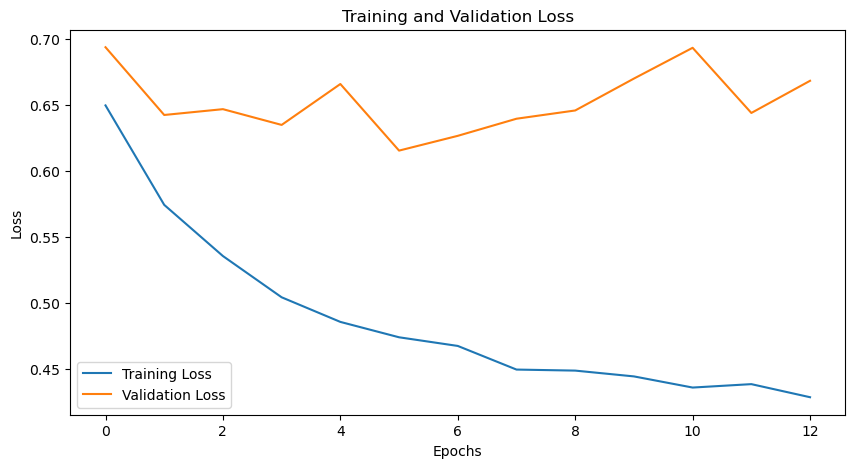

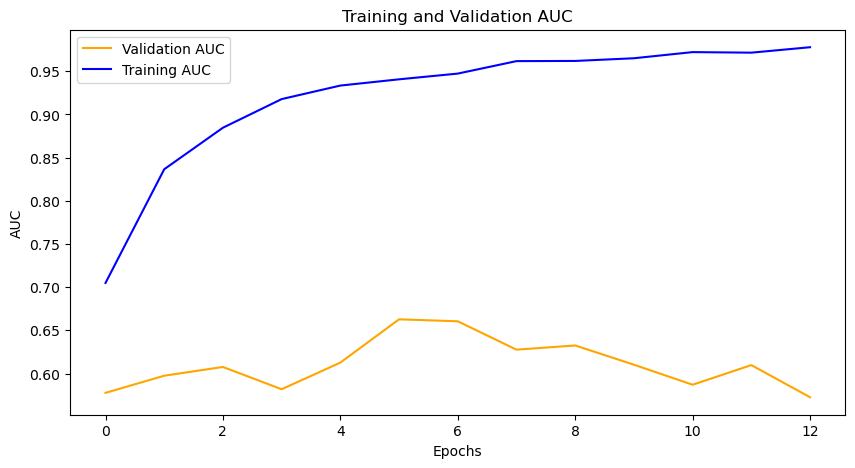

Results DataFrame saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_1/results_df.csv
Patient results saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_1/patient_results.csv
Patient metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_1/patient_metrics.json
Training and validation metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_1/loss_auc_metrics.json
Experiment arguments saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_1/args.json
Fold 1 Metrics - Accuracy: 0.7857, AUC: 0.7500, Specificity: 0.8

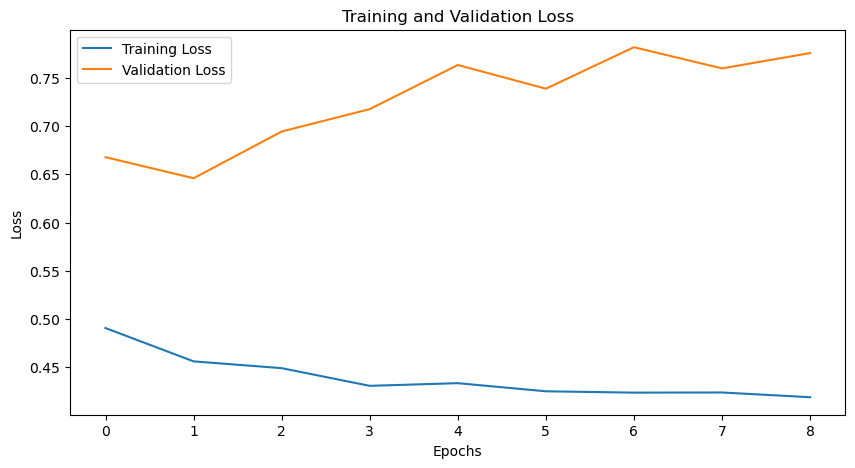

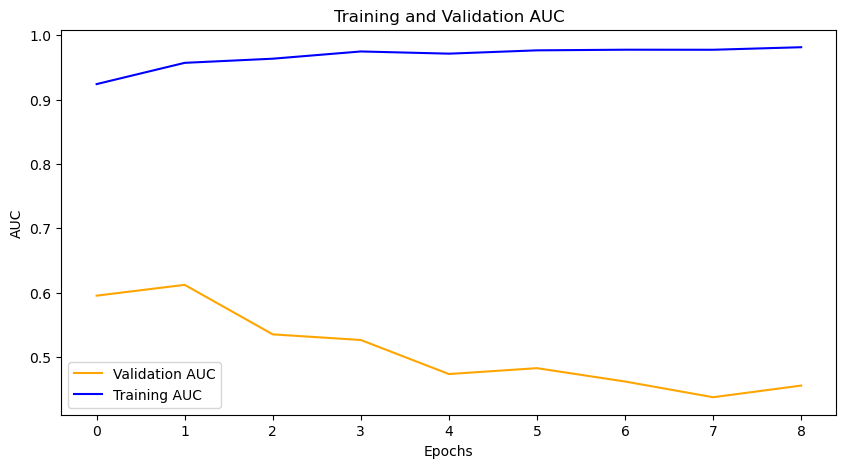

Results DataFrame saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_2/results_df.csv
Patient results saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_2/patient_results.csv
Patient metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_2/patient_metrics.json
Training and validation metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_2/loss_auc_metrics.json
Experiment arguments saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_2/args.json
Fold 2 Metrics - Accuracy: 0.7143, AUC: 0.5000, Specificity: 0.8

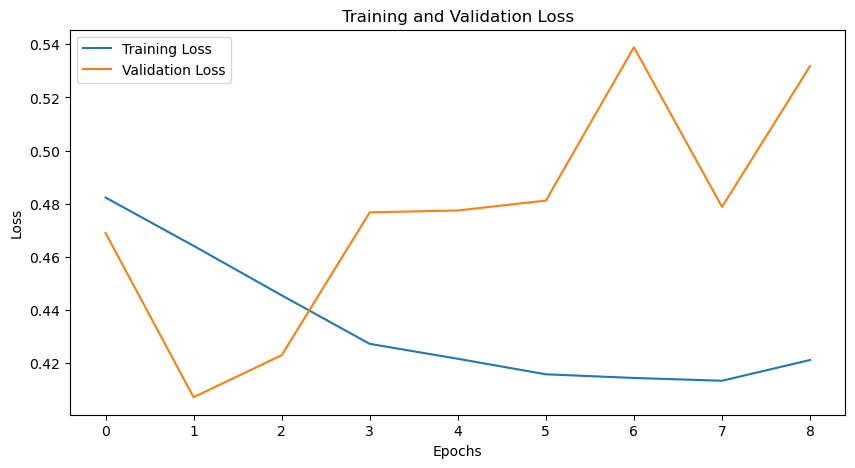

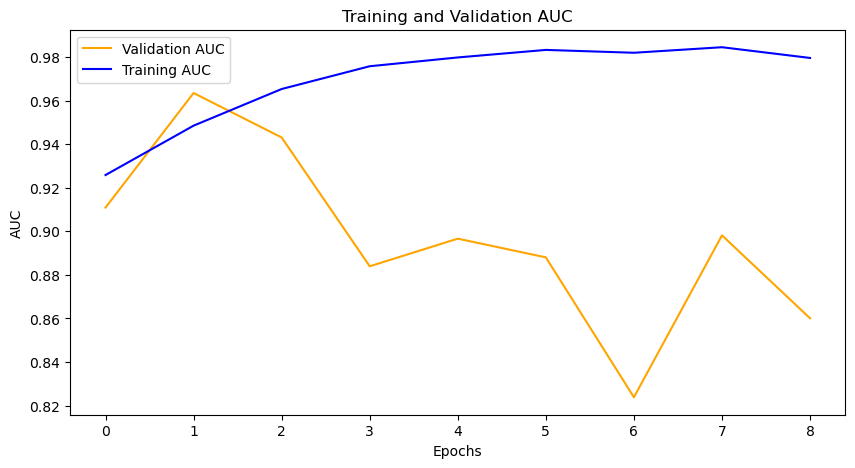

Results DataFrame saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_3/results_df.csv
Patient results saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_3/patient_results.csv
Patient metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_3/patient_metrics.json
Training and validation metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_3/loss_auc_metrics.json
Experiment arguments saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_3/args.json
Fold 3 Metrics - Accuracy: 0.9286, AUC: 1.0000, Specificity: 1.0

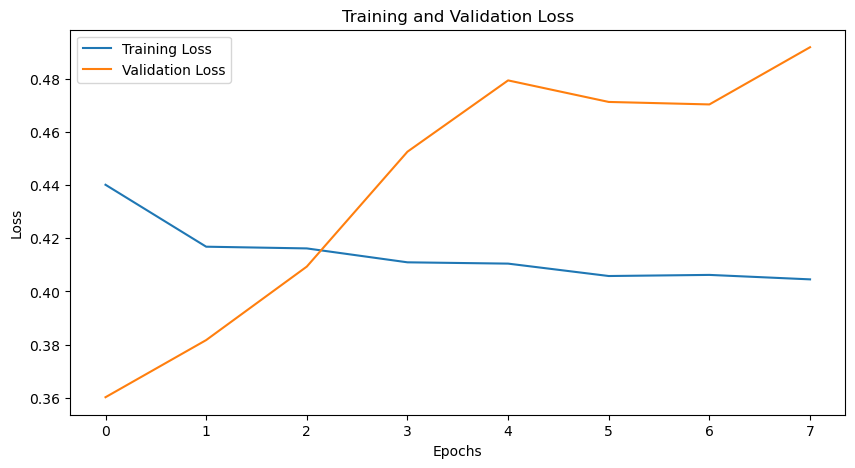

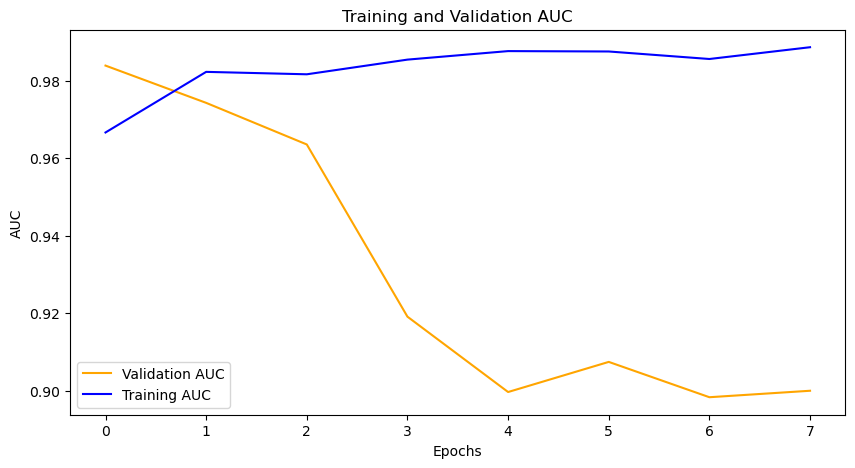

Results DataFrame saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_4/results_df.csv
Patient results saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_4/patient_results.csv
Patient metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_4/patient_metrics.json
Training and validation metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_4/loss_auc_metrics.json
Experiment arguments saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_4/args.json
Fold 4 Metrics - Accuracy: 0.9286, AUC: 1.0000, Specificity: 0.8

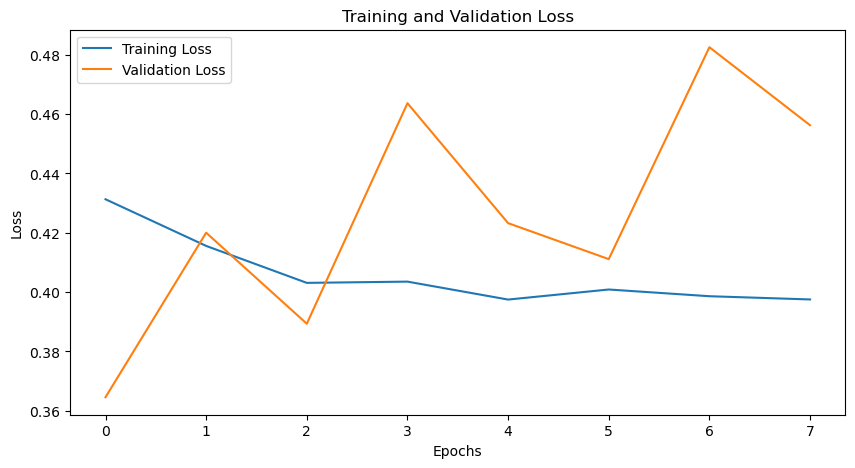

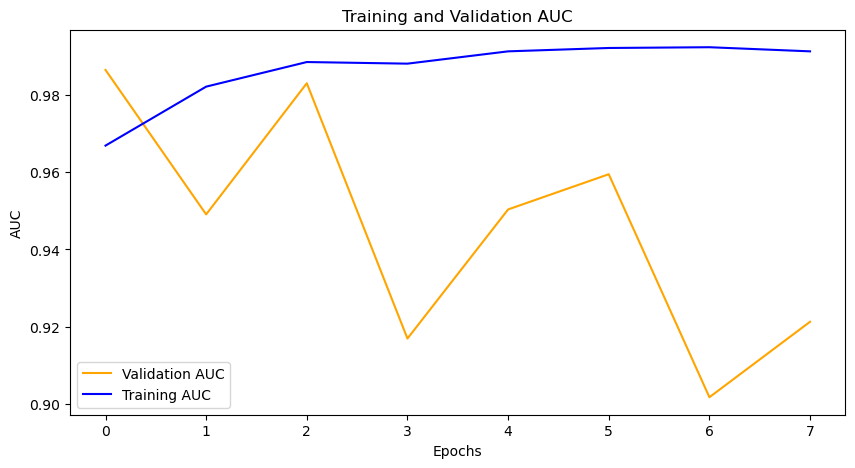

Results DataFrame saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_5/results_df.csv
Patient results saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_5/patient_results.csv
Patient metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_5/patient_metrics.json
Training and validation metrics saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_5/loss_auc_metrics.json
Experiment arguments saved to /home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/EfficientNet_all_audios_5s_with_1s_overlap_16kHz_top_db_20_3_best_models/fold_5/args.json
Fold 5 Metrics - Accuracy: 1.0000, AUC: 1.0000, Specificity: 1.0

In [16]:

cross_validate_and_save(
    audio_segments=audio_segments_HC_PD,
    labels_np=labels_HC_PD,
    patient_ids=patient_ids_HC_PD,
    args=args,
    audio_model=audio_model,
    audio_segments_AC = audio_segments_AC, 
    labels_AC = labels_AC, 
    patient_ids_AC = patient_ids_AC,
)